In [2]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import tarfile
from sklearn.cluster import KMeans
import contextily as ctx
import seaborn as sns

In [3]:
path = r"C:\Users\pranj\Downloads\Burned area products NASA FIRMS"
years_dir = [os.path.join(path,i) for i in os.listdir(path)]

In [3]:
# for dir in years_dir:
#     for filename in os.listdir(dir):
#             if filename.endswith(".tar.gz"):
#                 tar_path = os.path.join(dir, filename)
#                 print(f"Extracting: {tar_path}")

#                 with tarfile.open(tar_path, 'r:gz') as tar:  # Use 'r:gz' for .tar.gz files
#                     tar.extractall(path='Burned area files NASA')
#                     print(f"Extracted to: {'Burned area files NASA'}")

In [4]:
burnt_ls = []
for filename in os.listdir('Burned area files NASA'):
    if filename.endswith(".shp"):
        f = gpd.read_file(os.path.join(r'Burned area files NASA',filename))
        f['year'] = filename[14:18]
        burnt_ls.append(f)

In [5]:
burnt = pd.concat(burnt_ls,axis=0)

<AxesSubplot: >

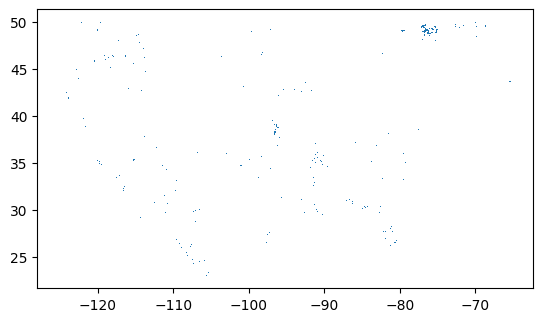

In [25]:
burnt.groupby('year').get_group('2023')['geometry'].plot()

In [35]:
burnt

,BurnDate,geometry,year
0,311,"POLYGON ((-122.06445 39.56738, -122.06006 39.5...",2000
1,306,"POLYGON ((-121.87988 38.86426, -121.87109 38.8...",2000
2,309,"POLYGON ((-121.75244 38.86426, -121.74805 38.8...",2000
3,309,"POLYGON ((-78.29492 38.65332, -78.28613 38.653...",2000
4,308,"POLYGON ((-78.3125 38.64014, -78.30371 38.6401...",2000
...,...,...,...
4637,298,"POLYGON ((-98.00439 25.92676, -98 25.92676, -9...",2024
4638,301,"POLYGON ((-98 25.91797, -97.99561 25.91797, -9...",2024
4639,299,"POLYGON ((-97.99561 25.91797, -97.99121 25.917...",2024
4640,276,"POLYGON ((-99.35791 25.54443, -99.35352 25.544...",2024


In [6]:
fire_CA = gpd.read_file(r"C:\Users\pranj\Downloads\DL_FIRE_M-C61_576403\fire_archive_M-C61_576403.shp")

In [7]:
fire_CA = fire_CA[fire_CA['CONFIDENCE']>80]

In [8]:
fire_CA['ordinal date']=fire_CA['ACQ_DATE'].dt.dayofyear
fire_CA['year'] = fire_CA['ACQ_DATE'].dt.year

In [10]:
fire_CA

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,ordinal date,year
6,38.8591,-120.4803,346.6,1.4,1.2,2000-11-02,1851,Terra,MODIS,95,6.03,285.9,95.5,D,0,POINT (-120.4803 38.8591),307,2000
8,39.0429,-122.6251,336.5,1.9,1.3,2000-11-02,1851,Terra,MODIS,90,6.03,287.5,93.6,D,0,POINT (-122.6251 39.0429),307,2000
10,39.0390,-122.6326,321.5,1.9,1.3,2000-11-02,1851,Terra,MODIS,81,6.03,287.0,47.9,D,0,POINT (-122.6326 39.039),307,2000
11,39.0371,-122.6106,331.6,1.9,1.3,2000-11-02,1851,Terra,MODIS,87,6.03,287.9,77.9,D,0,POINT (-122.6106 39.0371),307,2000
22,38.8583,-120.4905,318.5,1.6,1.2,2000-11-03,0556,Terra,MODIS,97,6.03,279.9,37.0,N,0,POINT (-120.4905 38.8583),308,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314694,40.1680,-121.6943,342.9,2.1,1.4,2024-07-31,2223,Aqua,MODIS,88,61.03,307.6,90.1,D,0,POINT (-121.6943 40.168),213,2024
314695,40.2091,-121.6498,348.1,2.1,1.4,2024-07-31,2223,Aqua,MODIS,85,61.03,301.4,143.0,D,0,POINT (-121.6498 40.2091),213,2024
314696,40.2071,-121.6752,354.2,2.1,1.4,2024-07-31,2223,Aqua,MODIS,91,61.03,308.5,173.7,D,0,POINT (-121.6752 40.2071),213,2024
314697,40.2404,-121.7285,352.8,2.1,1.4,2024-07-31,2223,Aqua,MODIS,95,61.03,305.3,158.1,D,0,POINT (-121.7285 40.2404),213,2024


In [9]:
%store fire_CA

Stored 'fire_CA' (GeoDataFrame)


In [10]:
#Storing back fire_CA data after converting the points to 1km*1km Poly
%store -r fire_CA 

In [11]:
fire_CA.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,ordinal date,year
6,38.8591,-120.4803,346.6,1.4,1.2,2000-11-02,1851,Terra,MODIS,95,6.03,285.9,95.5,D,0,"POLYGON ((-120.48604 38.85458, -120.4861 38.86...",307,2000
8,39.0429,-122.6251,336.5,1.9,1.3,2000-11-02,1851,Terra,MODIS,90,6.03,287.5,93.6,D,0,"POLYGON ((-122.63072 39.03828, -122.63104 39.0...",307,2000
10,39.0390,-122.6326,321.5,1.9,1.3,2000-11-02,1851,Terra,MODIS,81,6.03,287.0,47.9,D,0,"POLYGON ((-122.63822 39.03438, -122.63854 39.0...",307,2000
11,39.0371,-122.6106,331.6,1.9,1.3,2000-11-02,1851,Terra,MODIS,87,6.03,287.9,77.9,D,0,"POLYGON ((-122.61622 39.03248, -122.61654 39.0...",307,2000
22,38.8583,-120.4905,318.5,1.6,1.2,2000-11-03,0556,Terra,MODIS,97,6.03,279.9,37.0,N,0,"POLYGON ((-120.49624 38.85378, -120.4963 38.86...",308,2000


In [12]:
# Read the shapefile (Shapefile to crop the burned area data for CA state)
states_shapefile_url = 'https://firms.modaps.eosdis.nasa.gov/content/notebooks/exampleStatesShapefile2023(20m:coarse).zip'
states_gdf = gpd.read_file(states_shapefile_url)


<AxesSubplot: >

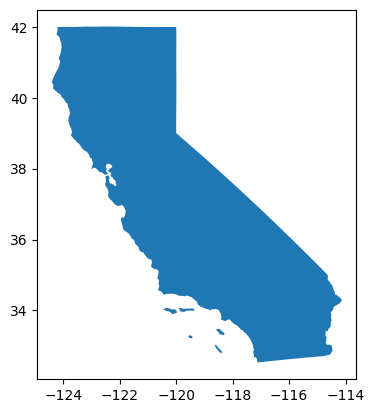

In [13]:
CA = states_gdf[states_gdf['NAME']=='California']
CA= CA.to_crs(burnt.crs)
CA.plot()

In [ ]:
burnt_CA = gpd.sjoin(burnt, CA, how="inner", predicate="intersects")
burnt_CA['geom_id'] = pd.factorize(burnt_CA['geometry'])[0] # This step is to assign same index to the repeating geometries

In [15]:
burnt_CA['geometry'] = burnt_CA['geometry'].to_crs("EPSG:9311") #9311 is crs espcially for US for area calculation purpose
burnt_CA['area_sqkm'] = burnt_CA['geometry'].area/10**6
burnt_CA = burnt_CA.to_crs("epsg:4326")

In [16]:
burnt_CA = burnt_CA[['BurnDate','year','geom_id','area_sqkm','geometry']]

"""Creating a list of ids of adjacent polygons for each geometry. 
Can help in better burn area calculation  estimate if burn dates of adjacent polygons are closer """

neighbors = []
burndates = []
for i in burnt_CA.year.unique():
    burnyear = burnt_CA[burnt_CA.year == i]
    adj_ids = burnyear.geometry.apply(lambda geom: burnyear[burnyear.geometry.touches(geom)]['geom_id'].tolist()).tolist()
    dates = burnyear.geometry.apply(lambda geom: burnyear[burnyear.geometry.touches(geom)]['BurnDate'].tolist()).tolist()
    neighbors.append(adj_ids)
    burndates.append(dates)
burnt_CA['neighbors'] = sum(neighbors,[])
burnt_CA['neigh_burndates'] = sum(burndates,[])
burnt_CA.head()

,BurnDate,year,geom_id,area_sqkm,geometry,neighbors,neigh_burndates
0,311,2000,0,0.184072,"POLYGON ((-122.06445 39.56738, -122.06006 39.5...",[],[]
1,306,2000,1,0.557788,"POLYGON ((-121.87988 38.86426, -121.87109 38.8...",[],[]
2,309,2000,2,0.185925,"POLYGON ((-121.75244 38.86426, -121.74805 38.8...",[],[]
57,314,2000,3,0.187919,"POLYGON ((-121.23828 38.09521, -121.23389 38.0...",[],[]
85,321,2000,4,0.575713,"POLYGON ((-119.5376 36.51758, -119.52441 36.51...",[6],[319]


In [ ]:
burnt_CA['area_sqkm'].describe()

count    78954.000000
mean         1.021121
std          5.671007
min          0.177420
25%          0.185372
50%          0.356422
75%          0.559696
max        403.839139
Name: area_sqkm, dtype: float64

: 

In [15]:
# # Extract centroids
# burnt_CA['centroid'] = burnt_CA['geometry'].centroid
# coords = burnt_CA['centroid'].apply(lambda point: [point.x, point.y]).tolist()

# # Apply KMeans clustering
# kmeans = KMeans(n_clusters=10, random_state=0, n_init=10)
# burnt_CA['cluster'] = kmeans.fit_predict(coords)

# burnt_CA

In [16]:
# burnt_CA[burnt_CA['year']=='2023'].groupby('cluster')['BurnDate'].describe()

In [17]:
## Spatially joining the FIRMS data with burned area dataset
# simple_join = gpd.sjoin_nearest(fire_CA, burnt_CA, how="left", max_distance=0.0045).dropna()  
simple_join = gpd.sjoin(fire_CA, burnt_CA, how="left", predicate='intersects').dropna()
simple_join['year_left'],simple_join['year_right'] = simple_join['year_left'].astype(int),simple_join['year_right'].astype(int)
year_overlap = simple_join[simple_join['year_left']==simple_join['year_right']]
date_buffer = year_overlap[(year_overlap['BurnDate']-year_overlap['ordinal date']).isin(range(-30,30))]


In [18]:
date_buffer['area_sqkm'] = date_buffer.groupby('geometry')['area_sqkm'].transform('sum') #Transform function sums in place without dropping duplicate values of groupby
date_buffer = date_buffer.drop_duplicates(subset='geometry')

C:\Users\pranj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [20]:
date_buffer.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,...,geometry,ordinal date,year_left,index_right,BurnDate,year_right,geom_id,area_sqkm,neighbors,neigh_burndates
714,38.9333,-121.7343,327.3,1.0,1.0,2001-03-22,1913,Terra,MODIS,84,...,"POLYGON ((-121.73997 38.92872, -121.74018 38.9...",81,2001,477.0,80.0,2001,426.0,1.857430,"[427, 429, 430]","[74, 70, 73]"
769,39.1755,-122.1915,324.4,1.3,1.1,2001-03-27,1932,Terra,MODIS,83,...,"POLYGON ((-122.19716 39.1709, -122.19743 39.17...",86,2001,395.0,87.0,2001,358.0,4.072479,"[359, 363, 364, 359]","[89, 79, 79, 274]"
839,39.5083,-122.1757,323.0,2.3,1.5,2001-04-01,1950,Terra,MODIS,82,...,"POLYGON ((-122.18138 39.5037, -122.18165 39.51...",91,2001,120.0,88.0,2001,95.0,2.026472,"[94, 96, 97, 110, 115, 97]","[86, 69, 71, 81, 87, 259]"
840,39.5026,-122.1503,321.6,2.3,1.5,2001-04-01,1950,Terra,MODIS,81,...,"POLYGON ((-122.15598 39.498, -122.15625 39.507...",91,2001,139.0,72.0,2001,114.0,4.421854,"[94, 97, 103, 104, 136, 97, 1292, 1293, 1310, ...","[86, 71, 88, 86, 74, 259, 262, 264, 267, 270]"
841,38.9697,-121.4702,345.5,2.6,1.5,2001-04-01,1950,Terra,MODIS,94,...,"POLYGON ((-121.47589 38.96513, -121.47607 38.9...",91,2001,436.0,77.0,2001,385.0,0.371320,[],[]


In [21]:
%store date_buffer

Stored 'date_buffer' (GeoDataFrame)


In [22]:
len(simple_join), len(year_overlap), len(date_buffer)

(601143, 411609, 123147)

In [23]:
#Fire range within a pixel
date_buffer.groupby('geom_id')['FRP'].apply(lambda x:max(x)-min(x)).describe()

count    27146.000000
mean       287.510436
std        683.914588
min          0.000000
25%          0.000000
50%         43.300000
75%        257.000000
max      11873.500000
Name: FRP, dtype: float64

In [113]:
#Fire intensity variation within a pixel
date_buffer.groupby('index_right')['FRP'].apply(lambda x:x.std()/x.mean())

index_right
0.0        0.065473
3.0             NaN
9.0             NaN
10.0       1.186516
11.0            NaN
             ...   
15730.0    1.357642
15732.0         NaN
15815.0    1.002827
15817.0         NaN
15820.0         NaN
Name: FRP, Length: 11499, dtype: float64

In [38]:
date_buffer.columns

Index(['LATITUDE', 'LONGITUDE', 'BRIGHTNESS', 'SCAN', 'TRACK', 'ACQ_DATE',
       'ACQ_TIME', 'SATELLITE', 'INSTRUMENT', 'CONFIDENCE', 'VERSION',
       'BRIGHT_T31', 'FRP', 'DAYNIGHT', 'TYPE', 'geometry', 'ordinal date',
       'year_left', 'index_right', 'BurnDate', 'year_right', 'geom_id',
       'neighbors', 'neigh_burndates'],
      dtype='object')

In [24]:
#Spatial autocorrelation
from esda.moran import Moran
from libpysal.weights import DistanceBand
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Create a spatial weights matrix (considering neighbors within 500m)
l=[]
for i in date_buffer['year_left'].unique():
    m,p,month=[],[],[]
    for j in range(1,13,3):
        try:
            # Compute Moran’s I for FRP values
            w =  DistanceBand.from_dataframe(date_buffer[(date_buffer['ACQ_DATE'].dt.month.isin(range(j,j+3)))&(date_buffer['year_left']==i)], threshold=0.0045, silence_warnings=True)
            moran = Moran(date_buffer[(date_buffer['ACQ_DATE'].dt.month.isin(range(j,j+3)))&(date_buffer['year_left']==i)]["FRP"], w)
            print(f"Moran’s I: {moran.I}, p-value: {moran.p_norm}", j,i)
            m.append(moran.I)
            p.append(moran.p_norm)
            month.append(j)

        except:
            pass
    df=pd.DataFrame({'m':m, 'p':p,'year':[i]*len(m),'month':month})
    l.append(df)

Moran’s I: nan, p-value: nan 1 2001
Moran’s I: -2.295053674034974, p-value: 0.01910194392985934 4 2001
Moran’s I: -0.03381569177169541, p-value: 0.6815013003968706 7 2001
Moran’s I: -0.6576465136593385, p-value: 0.35968673022097253 10 2001
Moran’s I: nan, p-value: nan 1 2002
Moran’s I: 0.02861956260914169, p-value: 0.8378839068676391 4 2002
Moran’s I: 0.008219097670324547, p-value: 0.8217477255832473 7 2002
Moran’s I: 0.6152463647452011, p-value: 0.04949778991963691 10 2002
Moran’s I: nan, p-value: nan 1 2003
Moran’s I: -1.1950998174110647, p-value: 0.23045679800339758 4 2003
Moran’s I: 0.13253291349455582, p-value: 0.005269713399895412 7 2003
Moran’s I: 0.06999532863152977, p-value: 0.04511989509451253 10 2003
Moran’s I: -0.252642323088684, p-value: 0.7491105803166608 1 2004
Moran’s I: 0.09578821717877525, p-value: 0.5790305515568457 4 2004
Moran’s I: 0.04810953665197641, p-value: 0.4457204705012703 7 2004
Moran’s I: 0.014852998067498702, p-value: 0.8723222471070793 10 2004
Moran’s I:

In [25]:
moran_df = pd.concat(l)
moran_df = moran_df[moran_df['p']<0.05]

In [26]:
moran_df

,m,p,year,month
1,-2.295054,1.910194e-02,2001,4
3,0.615246,4.949779e-02,2002,10
2,0.132533,5.269713e-03,2003,7
3,0.069995,4.511990e-02,2003,10
2,0.064159,7.842502e-03,2006,7
3,0.356141,1.269812e-02,2006,10
3,1.029359,2.386228e-117,2007,10
1,0.187879,5.515437e-09,2008,4
2,0.164382,2.578596e-16,2008,7
2,0.121219,8.796380e-06,2009,7


C:\Users\pranj\AppData\Local\Temp\ipykernel_44608\4238828585.py:21: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[1].legend(moran_df['year'].unique(),fontsize = 8)


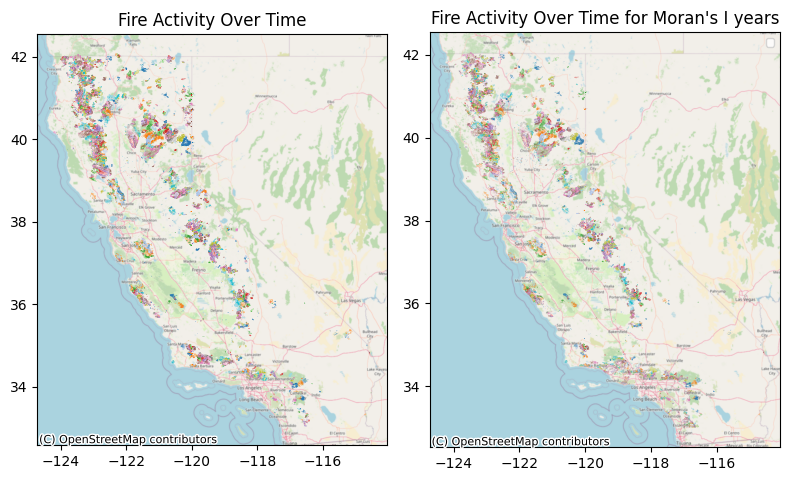

In [27]:
import matplotlib.pyplot as plt
import contextily as ctx 
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 2, figsize=(8, 14))

df = date_buffer[(date_buffer['ACQ_DATE'].dt.month.isin(range(7,10)))]
df.groupby('year_left').plot(ax=ax[0], label=f"Year {i}",markersize=5, cmap = 'tab20')
ctx.add_basemap(ax[0], crs=df.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
ax[0].set_title("Fire Activity Over Time")

# ax[0].legend(handles=handles,fontsize = 8)

# Just looking at the years having significant spatial correlation
for i in range(len(moran_df)):
    df = date_buffer[(date_buffer['year_left']==moran_df['year'].iloc[i])&(date_buffer['ACQ_DATE'].dt.month.isin(range(moran_df['month'].iloc[i],moran_df['month'].iloc[i]+3)))]
    if len(df)>0:
        df.plot(ax=ax[1], markersize=5, label=f"Year {i}", alpha=0.6, cmap = 'tab20')
ctx.add_basemap(ax[1], crs=df.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
ax[1].set_title("Fire Activity Over Time for Moran's I years")
ax[1].legend(moran_df['year'].unique(),fontsize = 8)

plt.tight_layout()
plt.show()

In [119]:
date_buffer.groupby(['geom_id','year_left'])['BurnDate'].apply(lambda x:max(x)-min(x)).reset_index('geom_id')

,geom_id,BurnDate
year_left,,
2001,108.0,0.0
2001,112.0,0.0
2001,115.0,0.0
2022,142.0,0.0
2001,290.0,0.0
...,...,...
2024,75035.0,0.0
2024,75036.0,0.0
2024,75046.0,0.0


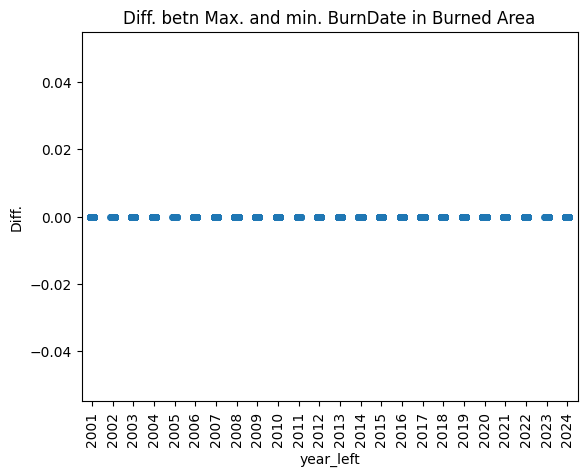

Text(0.5, 1.0, 'Count of fires in Burned Area')

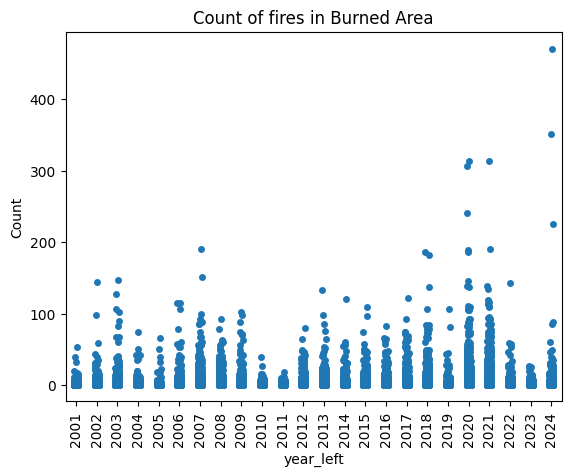

In [29]:
import seaborn as sns
sns.stripplot(x ="year_left", y= 'BurnDate', data= date_buffer.groupby(['geom_id','year_left'])['BurnDate'].apply(lambda x:max(x)-min(x)).reset_index("year_left"))
plt.xticks(rotation=90);
plt.ylabel("Diff.")
plt.title('Diff. betn Max. and min. BurnDate in Burned Area')
plt.show()
sns.stripplot(x ="year_left", y= 'BurnDate', data= date_buffer.groupby(['geom_id','year_left'])['BurnDate'].count().reset_index("year_left"))
plt.xticks(rotation=90);
plt.ylabel("Count")
plt.title('Count of fires in Burned Area')

In [ ]:
# Trying methods to integrate the burned adjacent geometries into one polygon

burnt_CA = burnt_CA.to_crs(epsg=3310)  # California Albers (meters)

# Apply buffer in meters
l=[]
for i in burnt_CA['year'].unique():
    buffered_gdf = burnt_CA[burnt_CA['year']==i].buffer(500)  # 500 meters
    # buffered_gdf['year'] = i
    # Convert back to WGS84 if needed
    buffered_gdf = buffered_gdf.to_crs(epsg=4326)
    l.append(gpd.GeoDataFrame(geometry=[buffered_gdf.union_all()]).explode())
buff =gpd.GeoDataFrame(pd.concat(l, ignore_index=True))

In [ ]:
"""Since the spatial join of Burn area and FIRMS data files results in some data loss, 
trying to see if dissolve technique helps in accounting for adjacent burn area polygons 
which might be lost during sjon"""

from shapely.geometry import Point
from sklearn.cluster import DBSCAN
import numpy as np

burnt_2020 = burnt_CA[burnt_CA['year']=='2020']
coords = np.array([(p.x, p.y) for p in burnt_2020.centroid])
# Apply DBSCAN clustering (eps is the distance threshold)
db = DBSCAN(eps=500, min_samples=1).fit(coords)  # Adjust eps as needed

# Assign cluster labels to the GeoDataFrame
burnt_2020["cluster"] = db.labels_

# Merge polygons within each cluster
burnt_2020.dissolve(by="cluster")


""" While this technique is useful in clustering adjacent polygons, it results in data loss as the dissolved polygons might 
have different burn date and if burn dates are far from each other, this will give false results in further analysis """

C:\Users\pranj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,geometry,BurnDate,year,geom_id
cluster,,,,
0,"POLYGON ((-177298.69 154298.496, -177676.845 1...",4,2020,224
1,"POLYGON ((-132699.54 128540.775, -132320.191 1...",29,2020,48944
2,"POLYGON ((-133086.83 128058.6, -132707.458 128...",31,2020,48945
3,"POLYGON ((-46364.786 98778.915, -45984.058 987...",29,2020,48946
4,"POLYGON ((-48271.299 98301.444, -48274.169 978...",31,2020,48947
...,...,...,...,...
10076,"POLYGON ((213878.478 -470911.074, 215099.88 -4...",337,2020,61886
10077,"POLYGON ((220429.246 -472211.514, 220836.441 -...",341,2020,61887
10078,"POLYGON ((214297.498 -471388.32, 215926.122 -4...",338,2020,61888


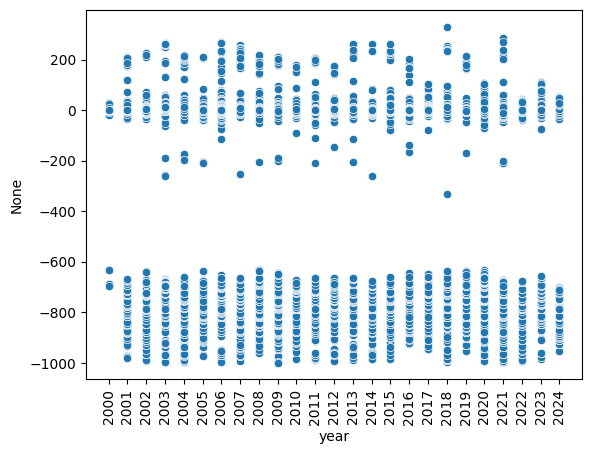

In [34]:
import seaborn as sns
sns.scatterplot(x = burnt_CA['year'], y = burnt_CA['BurnDate'] - burnt_CA['neigh_burndates'].apply(lambda x:min(x) if len(x)>0 else 1000))
plt.xticks(rotation = 90);

' This approach helps in identifying the locations that are prone to frequent fires \nif they have neighboring location which also had fires detected '

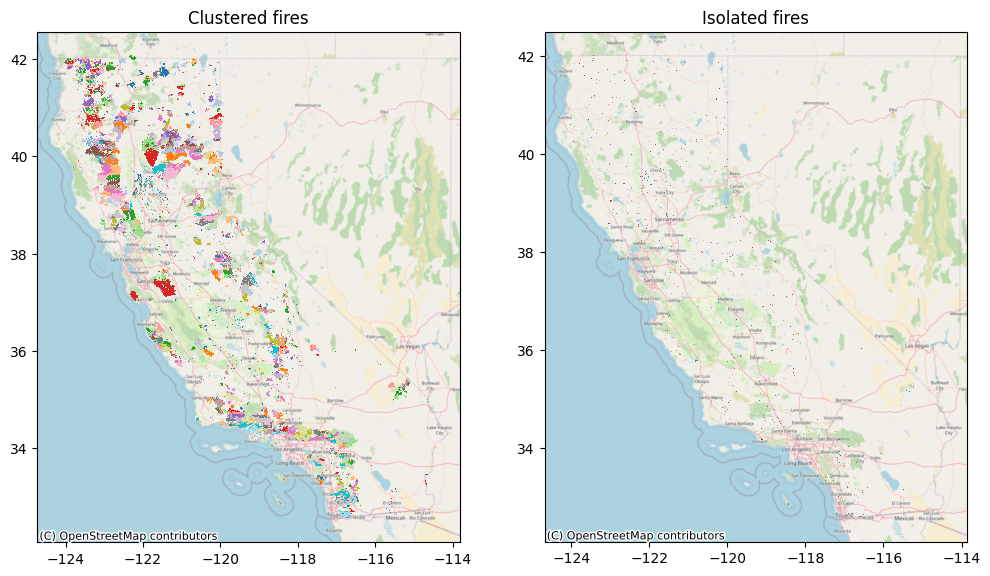

In [36]:
fig,ax = plt.subplots(1,2,figsize=(12,10))
burnt_CA[~burnt_CA['neighbors'].apply(lambda x: x==[])==True].groupby('year').plot(ax=ax[0],cmap = 'tab20');
burnt_CA[burnt_CA['neighbors'].apply(lambda x: x==[])==True].groupby('year').plot(ax=ax[1],cmap = 'tab20',markersize=30); # Separating out geometries which don't have neighbors
ctx.add_basemap(ax[0], crs=burnt_CA.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
ctx.add_basemap(ax[1], crs=burnt_CA.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
ax[0].set_title('Clustered fires')
ax[1].set_title('Isolated fires')

""" This approach helps in identifying the locations that are prone to frequent fires 
if they have neighboring location which also had fires detected """


In [ ]:
fire_freq = gpd.GeoDataFrame(date_buffer.groupby(['geom_id','year_left']).agg({'BurnDate': 'count', 'geometry': 'first'}).reset_index(),geometry='geometry',crs = fire_CA.crs)
fire_freq[fire_freq['BurnDate']>50].explore('BurnDate',height=400, width=500,control_scale=False)

: 

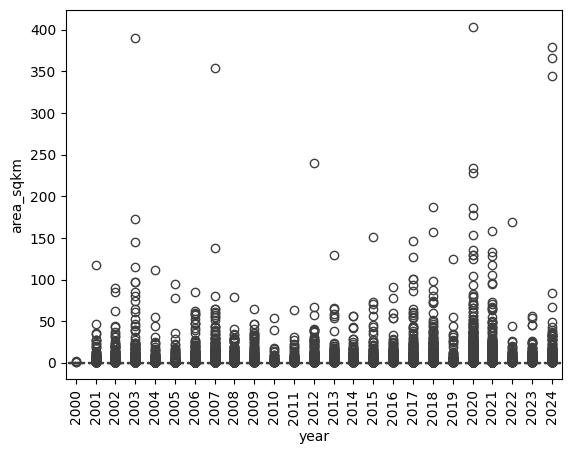

In [127]:
import seaborn as sns
import mplleaflet
sns.boxplot(x=burnt_CA['year'],y=burnt_CA['area_sqkm'])
plt.xticks(rotation=90);
burnt_CA.groupby('year')['area_sqkm'].describe()
burnt_CA[burnt_CA['area_sqkm'].isin(burnt_CA.groupby('year')['area_sqkm'].max())].explore(column='year',height=400, width=500,control_scale=False)
